# 高遠球程式(舊)

**用途**：早期版本，比較 LSTM / CNN / CNN+LSTM 三種架構在高遠球資料上的表現

**輸入**：`./data/grade_and_comment_separate.json`

**輸出**：`models/lstm_base_model1~5.keras`、`models/cnn_base_model1~5.keras`、`models/cnn_lstm_base_model1~5.keras`

**狀態**：🗄️ 已棄用 / 僅供歷史參考
（現在 `專題/models/` 裡的 `model1.keras`~`model5.keras` 不是這份存的，是「高遠球程式(新).ipynb」存的）

**更新日期**：2026-08-15

In [58]:
import json
import numpy as np
import pandas as pd

In [236]:
with open('./data/grade_and_comment_separate.json', 'r', encoding='utf-8') as file:
    data = json.load(file)
df = pd.DataFrame(data)
display(df)

,檔名,評語,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,h001_44333_1,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.124, 4.53, 4.132, 4.308, 4.462, 5.16, 5.94,...","[3.692, 5.22, 5.966, 5.586, 4.494, 3.394, 3.37...","[4.186, 3.448, 1.836, 1.03, 1.162, 1.626, 2.55...","[-1.906, -1.442, -0.992, -0.414, -0.468, -1.36...","[-1.14, -0.952, -0.794, -0.626, -0.598, -1.134...","[-0.04, -0.048, -0.19, -0.352, -0.332, 0.002, ..."
1,h001_44333_10,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.328, 5.19, 5.226, 5.446, 5.74, 5.954, 5.922...","[7.996, 8.284, 8.554, 8.426, 8.136, 7.914, 8.1...","[0.446, 0.442, 0.404, -0.358, -1.192, -1.29, -...","[-0.386, -0.218, -0.09, 0.182, 0.25, -0.172, -...","[-1.212, -1.264, -1.19, -0.968, -0.708, -0.666...","[0.512, 0.674, 0.766, 0.684, 0.592, 0.582, 0.6..."
2,h001_44333_11,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[2.642, 3.136, 4.28, 5.506, 5.918, 6.172, 5.74...","[6.086, 7.234, 8.492, 9.034, 8.772, 8.822, 8.9...","[2.45, 1.482, 1.194, 1.724, 1.128, 1.738, 2.41...","[-2.606, -2.326, -1.872, -1.804, -1.896, -1.85...","[-1.67, -1.578, -1.64, -1.724, -1.684, -1.612,...","[0.632, 0.52, 0.268, 0.122, 0.158, 0.23, 0.234..."
3,h001_44333_12,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[6.69, 6.928, 6.838, 6.484, 6.148, 6.188, 6.80...","[5.562, 6.346, 8.194, 10.77, 12.856, 13.026, 1...","[2.224, 3.058, 3.69, 3.882, 2.536, 1.508, 1.45...","[-3.788, -4.3, -4.564, -4.25, -3.094, -1.502, ...","[-1.134, -0.91, -0.726, -0.762, -0.76, -0.836,...","[-1.09, -1.522, -1.74, -1.678, -1.508, -1.566,..."
4,h001_44333_13,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.91, 6.052, 6.232, 6.458, 6.282, 6.014, 6.29...","[7.586, 7.048, 7.172, 7.59, 8.362, 9.42, 9.702...","[2.576, 2.534, 2.478, 2.844, 2.922, 2.086, 1.5...","[-1.93, -2.22, -2.438, -2.568, -2.484, -2.048,...","[-1.386, -1.38, -1.382, -1.384, -1.514, -1.486...","[-0.042, -0.198, -0.262, -0.22, -0.052, 0.268,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,h203_55555_5,標準,2,2,2,2,2,"[0.19, 0.638, 1.412, 2.292, 2.768, 3.526, 4.30...","[-0.912, -0.208, 1.534, 2.556, 2.876, 2.162, 1...","[2.758, 2.382, 2.258, 2.31, 2.746, 2.63, 2.62,...","[-3.504, -3.808, -4.004, -4.08, -4.084, -3.826...","[-1.596, -1.502, -1.448, -1.43, -1.422, -1.438...","[0.172, 0.032, -0.064, -0.148, -0.252, -0.282,..."
5905,h203_55555_6,標準,2,2,2,2,2,"[-8.946, -6.948, -4.988, -3.088, -1.666, -0.46...","[4.028, 1.77, -0.026, -0.354, 1.132, 4.114, 6....","[2.574, 0.678, -1.17, -1.816, -1.648, -1.192, ...","[-3.03, -2.768, -3.268, -4.174, -4.81, -4.76, ...","[-2.236, -1.95, -1.698, -1.498, -1.344, -1.254...","[-0.32, -0.386, -0.446, -0.578, -0.75, -0.888,..."
5906,h203_55555_7,標準,2,2,2,2,2,"[-5.296, -5.0, -5.332, -5.382, -5.012, -4.358,...","[7.06, 7.764, 8.554, 7.668, 5.266, 3.426, 3.08...","[9.18, 8.266, 7.968, 7.44, 6.782, 5.248, 3.05,...","[-4.87, -4.754, -4.276, -3.866, -3.716, -3.988...","[-4.084, -3.986, -3.88, -3.692, -3.472, -3.274...","[0.666, 0.372, 0.174, 0.054, -0.03, -0.156, -0..."
5907,h203_55555_8,標準,2,2,2,2,2,"[-2.82, -1.68, -0.336, 1.03, 2.004, 3.51, 5.03...","[1.808, 2.078, 3.22, 3.094, 1.974, 1.264, 1.36...","[-2.354, -3.094, -3.398, -3.714, -4.498, -4.96...","[-3.972, -4.036, -3.906, -3.686, -3.566, -3.50...","[-1.26, -0.96, -0.732, -0.516, -0.318, -0.138,...","[-0.78, -0.842, -0.914, -0.872, -0.862, -0.868..."


In [60]:
# define parameter
sample_count = len(data)
swing_time = 125 #1.25s
score_category_count = 3 #0,1,2

In [61]:
y1 = df['揮拍軌跡正確度'].values.astype(int)
y2 = df['揮拍速度流暢度'].values.astype(int)
y3 = df['手腕轉動時機正確度'].values.astype(int)
y4 = df['擊球時機正確度'].values.astype(int)
y5 = df['擊球位置正確度'].values.astype(int)

In [62]:
Y = [y1, y2, y3, y4, y5]

In [63]:
low_file = []
mid_file = []
high_file = []
test_file = []
val_file = []
train_file = []

In [64]:
overall_high_file = []
overall_mid_file = []
overall_low_file = []

for i in range(sample_count):
    avg = (y1[i] + y2[i] + y3[i] + y4[i] + y5[i])/5
    if avg == 2:
        overall_high_file.append(df['檔名'][i].split('_')[0])
    elif avg < 2 and avg > 0.7:
        overall_mid_file.append(df['檔名'][i].split('_')[0])
    else:
        overall_low_file.append(df['檔名'][i].split('_')[0])

overall_high_file = list(set(overall_high_file))
overall_mid_file = list(set(overall_mid_file))
overall_low_file = list(set(overall_low_file))

print(overall_high_file)
print(overall_mid_file)
print(overall_low_file)


['h124', 'h015', 'h198', 'h151', 'h006', 'h067', 'h126', 'h077', 'h064', 'h055', 'h174', 'h155', 'h081', 'h162', 'h152', 'h203', 'h047', 'h125', 'h103', 'h191', 'h005', 'h085', 'h115', 'h042', 'h104', 'h190', 'h194', 'h187', 'h144', 'h196', 'h024', 'h173', 'h014', 'h133', 'h158', 'h035', 'h073', 'h057', 'h156', 'h020', 'h117']
['h016', 'h028', 'h074', 'h148', 'h059', 'h011', 'h068', 'h177', 'h099', 'h202', 'h179', 'h078', 'h021', 'h022', 'h037', 'h128', 'h053', 'h039', 'h033', 'h186', 'h001', 'h072', 'h181', 'h061', 'h161', 'h176', 'h130', 'h036', 'h111', 'h052', 'h189', 'h142', 'h193', 'h109', 'h188', 'h116', 'h013', 'h122', 'h185', 'h017', 'h025', 'h147', 'h041', 'h029', 'h168', 'h157', 'h150', 'h031', 'h201', 'h192', 'h132', 'h062', 'h082', 'h050', 'h135', 'h140', 'h063', 'h160', 'h003', 'h089', 'h010', 'h086', 'h032', 'h195', 'h175', 'h199', 'h054', 'h129', 'h167', 'h087', 'h002', 'h030', 'h058', 'h060', 'h136', 'h040', 'h069', 'h149', 'h200', 'h165', 'h138', 'h139', 'h166', 'h197'

In [65]:
import random

In [66]:
random.shuffle(overall_high_file)
random.shuffle(overall_mid_file)
random.shuffle(overall_low_file)
high_test_quantity = int(len(overall_high_file)* 0.2)
mid_test_quantity = int(len(overall_mid_file) * 0.2)
low_test_quantity = int(len(overall_low_file) * 0.2)

overall_test_file = np.concatenate((np.array(overall_high_file[:high_test_quantity]), np.array(overall_mid_file[:mid_test_quantity]), np.array(overall_low_file[:low_test_quantity])), axis = 0)
print(overall_test_file)
print(len(overall_test_file))


['h162' 'h191' 'h103' 'h158' 'h067' 'h151' 'h077' 'h015' 'h062' 'h130'
 'h189' 'h160' 'h025' 'h109' 'h032' 'h028' 'h176' 'h179' 'h082' 'h111'
 'h202' 'h199' 'h192' 'h030' 'h089' 'h175' 'h044' 'h184' 'h170' 'h171'
 'h034' 'h038' 'h083' 'h114' 'h119' 'h137' 'h046' 'h141' 'h183']
39


In [67]:
def define_files(y):
    tmp_low = []
    tmp_mid = []
    tmp_high = []
    for i in range(sample_count):
        file_name = df['檔名'][i].split('_')[0]
        if file_name not in set(overall_test_file):
            if y[i] == 2:
                tmp_high.append(file_name)
            elif y[i] == 1:
                tmp_mid.append(file_name)
            else:
                tmp_low.append(file_name)
    high = list(set(tmp_high))
    mid = list(set(tmp_mid))
    low = list(set(tmp_low))
    low_file.append(high)
    mid_file.append(mid)
    high_file.append(low)

In [68]:
for element in Y:
    define_files(element)

In [69]:
#分訓練集和驗證集
def split_data(high_f, mid_f, low_f):
    random.shuffle(high_f)
    random.shuffle(mid_f)
    random.shuffle(low_f)
    high_index = int(len(high_f) * 0.2) #quantity of train file
    mid_index = int(len(mid_f) * 0.2) #quantity of train file
    low_index = int(len(low_f) * 0.2) #quantity of train file
    val_file.append(np.concatenate((np.array(high_f[:high_index]), np.array(mid_f[:mid_index]), np.array(low_f[:low_index])), axis = 0))
    train_file.append(np.concatenate((np.array(high_f[high_index:]), np.array(mid_f[mid_index:]), np.array(low_f[low_index:])), axis = 0))



In [70]:
for i in range(5):
    split_data(high_file[i], mid_file[i], low_file[i])

In [71]:
columns = ['揮拍軌跡分割','揮拍速度分割','手腕轉動分割','擊球時機分割','擊球位置分割']

for i in range(5):
    df[columns[i]] = df['檔名'].apply(
        lambda x: 
        1 if x.split('_')[0] in train_file[i] else 
        2 if x.split('_')[0] in val_file[i] else 
        0  # test file
    )

In [72]:
train_indices = []
val_indices = []

In [73]:
for i in range(5):
    train_indices.append(df[df[columns[i]] == 1].index)
    val_indices.append(df[df[columns[i]] == 2].index)
print(train_indices)
print(val_indices)

[Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908],
      dtype='int64', length=3845), Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908],
      dtype='int64', length=3839), Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908],
      dtype='int64', length=3805), Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908],
      dtype='int64', length=3821), Index([  20,   21,   22,   23,   24,   25,   26,   27,   28,   29,
       ...
       5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908],
      dtype='int64', length=3878)]
[Index([  40,   41,   42,   43,   44,   45,   46,   47,   48,   49,
       ...
       5226, 52

In [74]:
test_indices = df[df['揮拍軌跡分割'] == 0].index
print(test_indices)

Index([ 350,  351,  352,  353,  354,  355,  356,  357,  358,  359,
       ...
       5869, 5870, 5871, 5872, 5873, 5874, 5875, 5876, 5877, 5878],
      dtype='int64', length=1160)


In [ ]:
for i in range(5):
    print(train_indices[i].tolist())
for i in range(5):
    print(val_indices[i].tolist())
print(test_indices.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 26

In [76]:
from sklearn.preprocessing import MinMaxScaler

In [77]:
#-1,125
scaler = MinMaxScaler() #normalization
std_x_acc = scaler.fit_transform(np.concatenate(df['x軸加速度'].tolist()).reshape(-1, 1))
std_y_acc = scaler.fit_transform(np.concatenate(df['y軸加速度'].tolist()).reshape(-1, 1))
std_z_acc = scaler.fit_transform(np.concatenate(df['z軸加速度'].tolist()).reshape(-1, 1))
std_x_ang = scaler.fit_transform(np.concatenate(df['x軸角加速度'].tolist()).reshape(-1, 1))
std_y_ang = scaler.fit_transform(np.concatenate(df['y軸角加速度'].tolist()).reshape(-1, 1))
std_z_ang = scaler.fit_transform(np.concatenate(df['z軸角加速度'].tolist()).reshape(-1, 1))

X = np.concatenate((std_x_acc, std_y_acc, std_z_acc, std_x_ang, std_y_ang, std_z_ang), axis = 1).reshape(-1, 125, 6)

In [78]:
print(X.shape)

(5909, 125, 6)


In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [80]:
def create_model(feature_count):
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.LSTM(units=16))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [81]:
def create_model_2(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model_m = Sequential()
    model_m.add(Input(shape=(swing_time, feature_count)))
    model_m.add(layers.Conv1D(16, 10, activation='relu', kernel_initializer=initializer))
    model_m.add(layers.MaxPooling1D(3))
    model_m.add(layers.Flatten())
    model_m.add(layers.Dense(score_category_count , activation='softmax'))
    model_m.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model_m.summary()
    return model_m

In [82]:
def create_model_3(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.Conv1D(16, 10, strides=1, padding='valid', activation='relu', kernel_initializer=initializer,  kernel_regularizer=regularizers.L2(0.03)))
    model.add(layers.MaxPooling1D(3))
    model.add(layers.LSTM(16))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [ ]:
lstm_model1 =  create_model(6)
lstm_model2 =  create_model(6)
lstm_model3 =  create_model(6)
lstm_model4 =  create_model(6)
lstm_model5 =  create_model(6)

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_45 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_49 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
#揮拍軌跡正確度
lstm_epochs_metrics_1 = lstm_model1.fit(X[train_indices[0]], y1[train_indices[0]],  validation_data=(X[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 20)

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.4518 - loss: 1.0571 - val_accuracy: 0.4856 - val_loss: 1.0053
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.4775 - loss: 1.0116 - val_accuracy: 0.4867 - val_loss: 0.9839
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.4772 - loss: 1.0021 - val_accuracy: 0.4867 - val_loss: 0.9782
Epoch 4/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.4752 - loss: 1.0033 - val_accuracy: 0.4867 - val_loss: 0.9770
Epoch 5/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.4871 - loss: 1.0023 - val_accuracy: 0.4867 - val_loss: 0.9763
Epoch 6/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.4845 - loss: 0.9996 - val_accuracy: 0.4867 - val_loss: 0.9753
Epoch 7/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.4746 - loss: 1.0026 - val_accuracy: 0.4867 - val_loss: 0.9749
Epoch 8/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.4801 - loss: 1.0015 - 

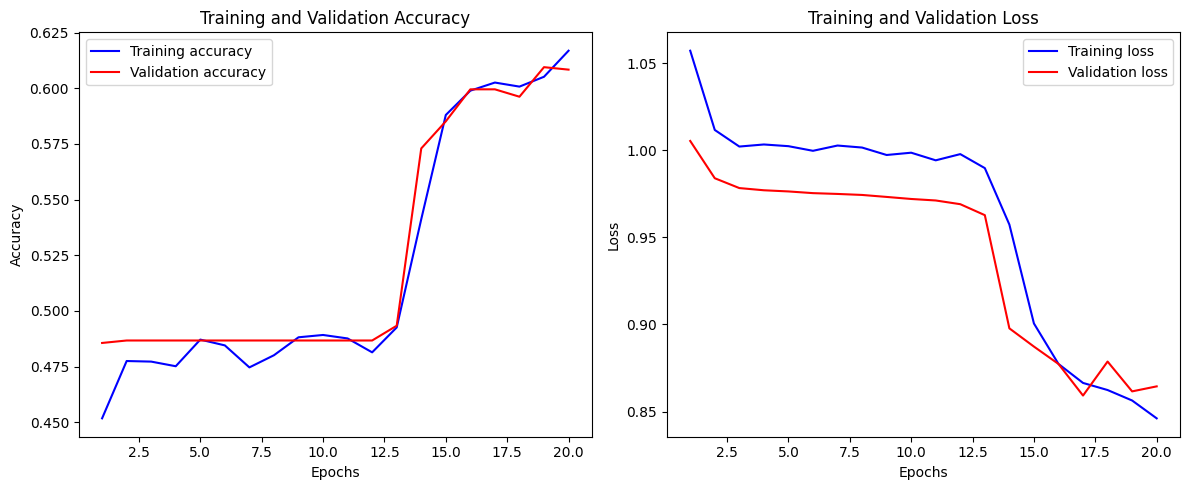

In [117]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [118]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = lstm_model1.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y1[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
整體驗證集準確度 (Overall Accuracy): 0.6164

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       119
     1分 (普通)     0.5945    0.7973    0.6811       592
      2分 (好)     0.6639    0.5412    0.5963       449

    accuracy                         0.6164      1160
   macro avg     0.4195    0.4462    0.4258      1160
weighted avg     0.5604    0.6164    0.5784      1160



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [120]:
lstm_model1.save("models/lstm_base_model1.keras")

In [74]:
print(X[:, :, 3:][train_indices[1]].shape)

(986, 125, 3)


In [121]:
#揮拍速度流暢度
lstm_epochs_metrics_2 = lstm_model2.fit(X[train_indices[1]], y2[train_indices[1]],  validation_data=(X[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 35)

Epoch 1/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.4428 - loss: 1.0693 - val_accuracy: 0.5176 - val_loss: 1.0221
Epoch 2/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4819 - loss: 1.0348 - val_accuracy: 0.5176 - val_loss: 1.0007
Epoch 3/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.4842 - loss: 1.0215 - val_accuracy: 0.5176 - val_loss: 0.9953
Epoch 4/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4853 - loss: 1.0229 - val_accuracy: 0.5176 - val_loss: 0.9921
Epoch 5/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.4887 - loss: 1.0158 - val_accuracy: 0.5176 - val_loss: 0.9898
Epoch 6/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.4819 - loss: 1.0191 - val_accuracy: 0.5176 - val_loss: 0.9869
Epoch 7/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4931 - loss: 1.0145 - val_accuracy: 0.5176 - val_loss: 0.9815
Epoch 8/35
240/240 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.4949 - loss: 1.0047 - 

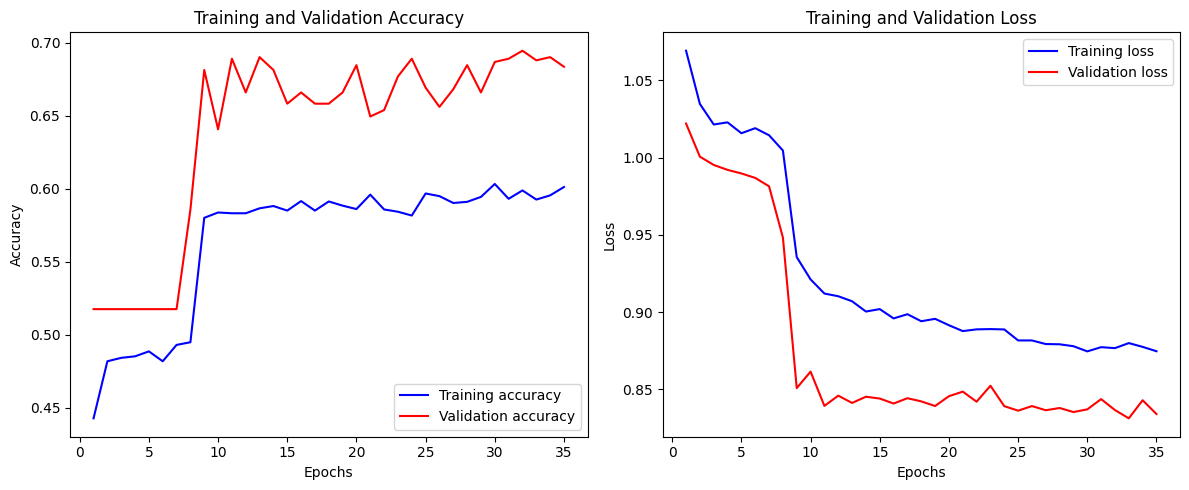

In [122]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [124]:
lstm_model2.save("models/lstm_base_model2.keras")

In [123]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model1.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y2[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
整體驗證集準確度 (Overall Accuracy): 0.5974

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.4472    0.2292    0.3030       240
     1分 (普通)     0.5722    0.6271    0.5984       531
      2分 (好)     0.6703    0.7841    0.7227       389

    accuracy                         0.5974      1160
   macro avg     0.5632    0.5468    0.5414      1160
weighted avg     0.5792    0.5974    0.5790      1160



In [132]:
#手腕轉動時機正確度
lstm_epochs_metrics_3 = lstm_model3.fit(X[train_indices[2]], y3[train_indices[2]],  validation_data=(X[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 60)

Epoch 1/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.3553 - loss: 1.0998 - val_accuracy: 0.3676 - val_loss: 1.0881
Epoch 2/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.3685 - loss: 1.0897 - val_accuracy: 0.3686 - val_loss: 1.0843
Epoch 3/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3769 - loss: 1.0837 - val_accuracy: 0.3686 - val_loss: 1.0835
Epoch 4/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.3829 - loss: 1.0827 - val_accuracy: 0.3665 - val_loss: 1.0834
Epoch 5/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.3798 - loss: 1.0831 - val_accuracy: 0.3739 - val_loss: 1.0832
Epoch 6/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3819 - loss: 1.0816 - val_accuracy: 0.3676 - val_loss: 1.0831
Epoch 7/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.3861 - loss: 1.0801 - val_accuracy: 0.4131 - val_loss: 1.0831
Epoch 8/60
238/238 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.3911 - loss: 1.0790 - 

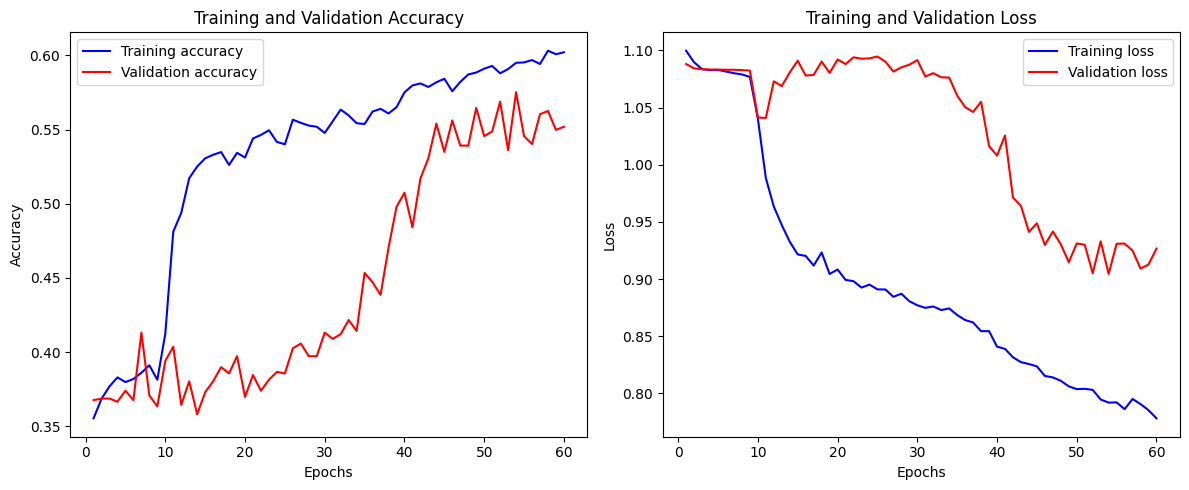

In [133]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [137]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = lstm_model3.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y3[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
整體驗證集準確度 (Overall Accuracy): 0.5802

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5578    0.9332    0.6982       419
     1分 (普通)     0.4842    0.2597    0.3381       412
      2分 (好)     0.7353    0.5319    0.6173       329

    accuracy                         0.5802      1160
   macro avg     0.5924    0.5749    0.5512      1160
weighted avg     0.5820    0.5802    0.5473      1160



In [182]:
lstm_model3.save("models/lstm_base_model3.keras")

In [135]:
#擊球時機正確度
lstm_epochs_metrics_4 = lstm_model4.fit(X[train_indices[3]], y4[train_indices[3]],  validation_data=(X[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 50)

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.3447 - loss: 1.1068 - val_accuracy: 0.3168 - val_loss: 1.0795
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4146 - loss: 1.0714 - val_accuracy: 0.4494 - val_loss: 1.0630
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4365 - loss: 1.0674 - val_accuracy: 0.4494 - val_loss: 1.0588
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4360 - loss: 1.0661 - val_accuracy: 0.4494 - val_loss: 1.0524
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4483 - loss: 1.0542 - val_accuracy: 0.4494 - val_loss: 1.0350
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4575 - loss: 1.0288 - val_accuracy: 0.4741 - val_loss: 0.9907
Epoch 7/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4952 - loss: 0.9991 - val_accuracy: 0.5765 - val_loss: 0.9520
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5080 - loss: 0.9765 - val_accu

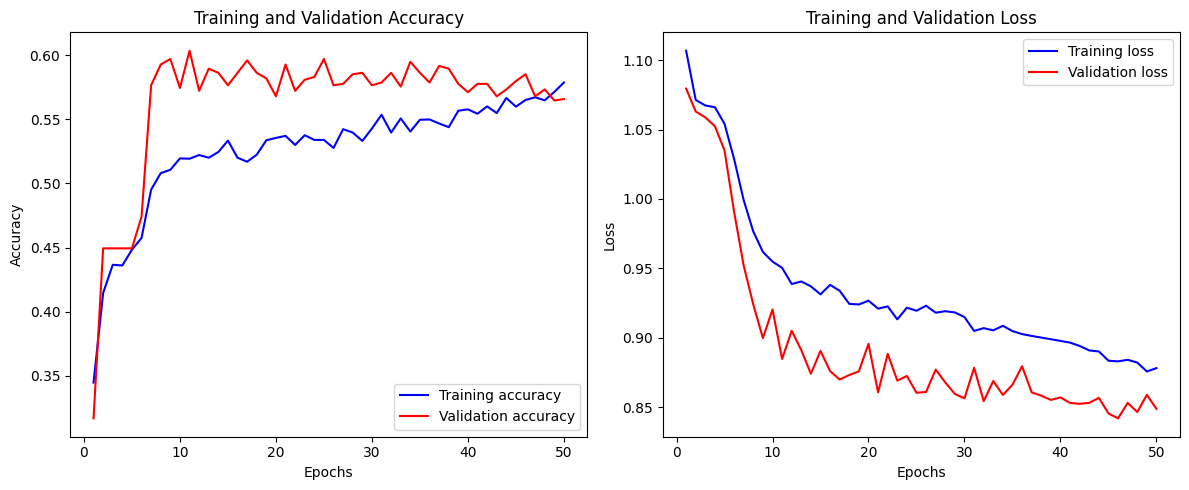

In [136]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [138]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = lstm_model4.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y4[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
整體驗證集準確度 (Overall Accuracy): 0.5698

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.4765    0.2630    0.3389       270
     1分 (普通)     0.5078    0.7186    0.5950       501
      2分 (好)     0.7616    0.5913    0.6657       389

    accuracy                         0.5698      1160
   macro avg     0.5820    0.5243    0.5332      1160
weighted avg     0.5856    0.5698    0.5591      1160



In [184]:
lstm_model4.save("models/lstm_base_model4.keras")

In [140]:
#擊球位置正確度(未train)
lstm_epochs_metrics_5 = lstm_model5.fit(X[train_indices[4]], y5[train_indices[4]],  validation_data=(X[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 30)

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3636 - loss: 1.0950 - val_accuracy: 0.3651 - val_loss: 1.0752
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3608 - loss: 1.0914 - val_accuracy: 0.4317 - val_loss: 1.0684
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3788 - loss: 1.0839 - val_accuracy: 0.4076 - val_loss: 1.0560
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3914 - loss: 1.0728 - val_accuracy: 0.4627 - val_loss: 0.9921
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4745 - loss: 1.0119 - val_accuracy: 0.4834 - val_loss: 0.9261
Epoch 6/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5049 - loss: 0.9914 - val_accuracy: 0.5017 - val_loss: 0.9151
Epoch 7/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5010 - loss: 0.9806 - val_accuracy: 0.5649 - val_loss: 0.8980
Epoch 8/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5111 - loss: 0.9656 - val_accu

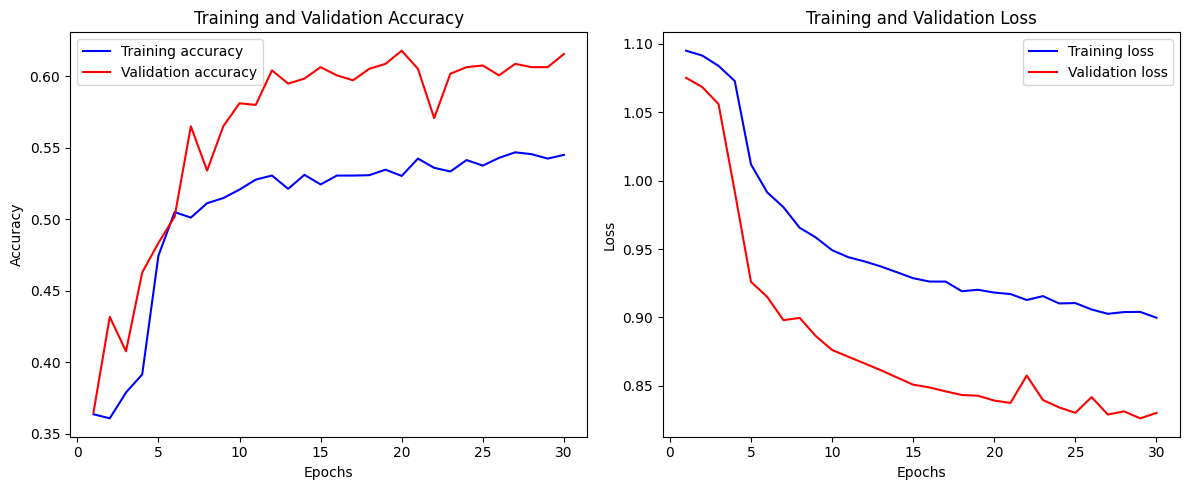

In [141]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [142]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = lstm_model5.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y5[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
整體驗證集準確度 (Overall Accuracy): 0.5638

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5521    0.7971    0.6523       419
     1分 (普通)     0.5073    0.3145    0.3883       442
      2分 (好)     0.6441    0.6054    0.6241       299

    accuracy                         0.5638      1160
   macro avg     0.5678    0.5723    0.5549      1160
weighted avg     0.5587    0.5638    0.5445      1160



In [185]:
lstm_model5.save("models/lstm_base_model5.keras")

In [157]:
cnn_model1  =  create_model_2(6)
cnn_model2  =  create_model_2(6)
cnn_model3  =  create_model_2(6)
cnn_model4  =  create_model_2(6)
cnn_model5  =  create_model_2(6)

Model: "sequential_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_74"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_29 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
cnn_epochs_metrics_1 = cnn_model1.fit(X[train_indices[0]], y1[train_indices[0]],  validation_data=(X[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 15)

Epoch 1/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5077 - loss: 0.9862 - val_accuracy: 0.4989 - val_loss: 0.9501
Epoch 2/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5678 - loss: 0.9350 - val_accuracy: 0.5852 - val_loss: 0.9043
Epoch 3/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6281 - loss: 0.8869 - val_accuracy: 0.6084 - val_loss: 0.8633
Epoch 4/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6523 - loss: 0.8429 - val_accuracy: 0.5774 - val_loss: 0.8471
Epoch 5/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6606 - loss: 0.8075 - val_accuracy: 0.5896 - val_loss: 0.8132
Epoch 6/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6629 - loss: 0.7806 - val_accuracy: 0.5907 - val_loss: 0.8193
Epoch 7/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6687 - loss: 0.7571 - val_accuracy: 0.5985 - val_loss: 0.7854
Epoch 8/15
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6718 - loss: 0.7394 - val_accuracy: 0.

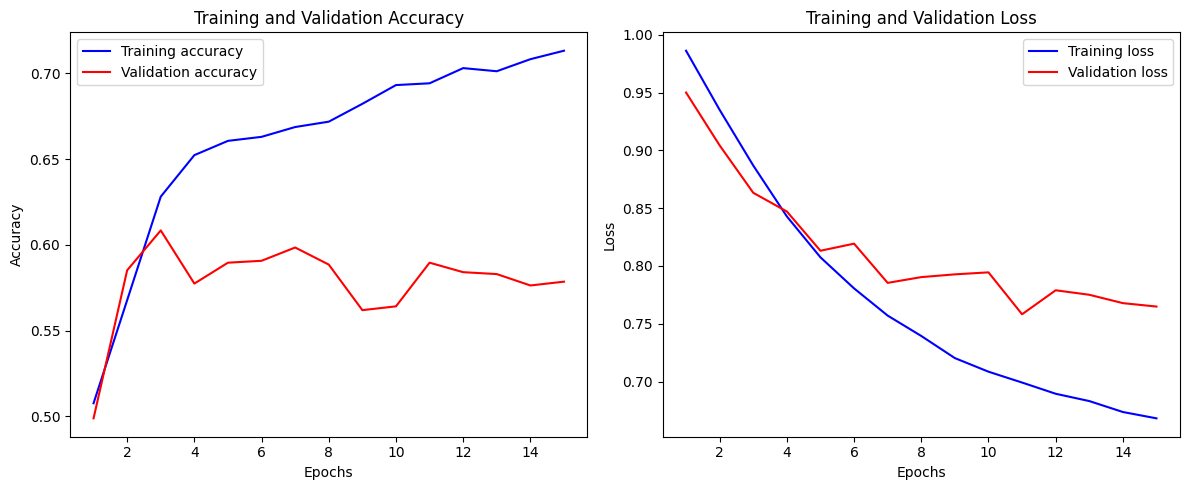

In [152]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [155]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_model1.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y1[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
整體驗證集準確度 (Overall Accuracy): 0.6845

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.4861    0.2941    0.3665       119
     1分 (普通)     0.6405    0.8699    0.7378       592
      2分 (好)     0.8592    0.5434    0.6658       449

    accuracy                         0.6845      1160
   macro avg     0.6619    0.5692    0.5900      1160
weighted avg     0.7093    0.6845    0.6718      1160



In [186]:
cnn_model1.save("models/cnn_base_model1.keras")

In [158]:
cnn_epochs_metrics_2 = cnn_model2.fit(X[train_indices[1]], y2[train_indices[1]],  validation_data=(X[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 30)

Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4947 - loss: 1.0105 - val_accuracy: 0.5176 - val_loss: 0.9730
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5249 - loss: 0.9701 - val_accuracy: 0.6484 - val_loss: 0.9209
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6046 - loss: 0.9085 - val_accuracy: 0.6297 - val_loss: 0.8643
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6361 - loss: 0.8529 - val_accuracy: 0.6286 - val_loss: 0.8255
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6457 - loss: 0.8104 - val_accuracy: 0.6275 - val_loss: 0.7970
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6551 - loss: 0.7793 - val_accuracy: 0.6242 - val_loss: 0.7845
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6637 - loss: 0.7532 - val_accuracy: 0.6231 - val_loss: 0.7779
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6598 - loss: 0.7339 - val_accuracy: 0.

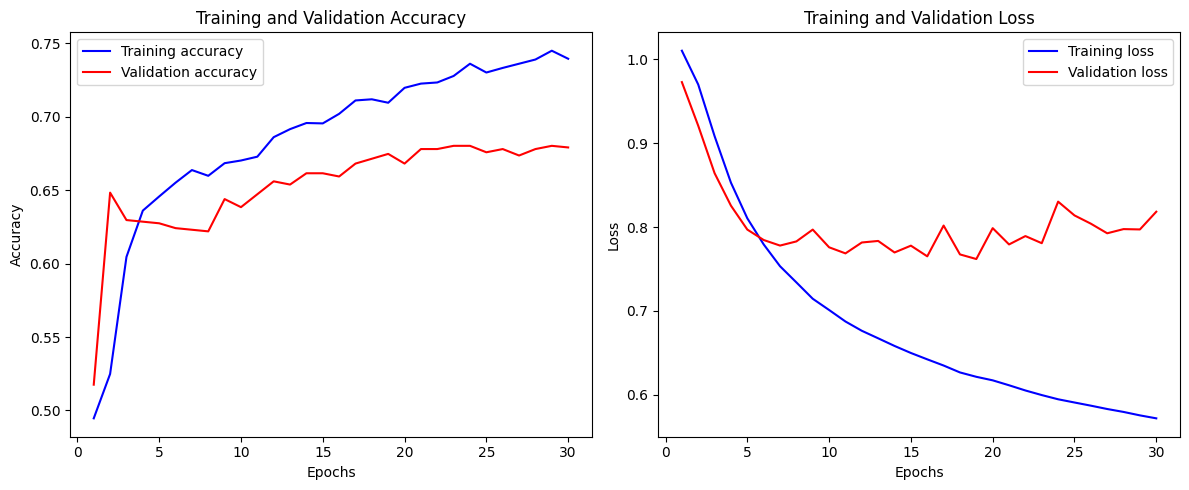

In [160]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [161]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_model2.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y2[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
整體驗證集準確度 (Overall Accuracy): 0.6750

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.6917    0.3458    0.4611       240
     1分 (普通)     0.5985    0.9153    0.7238       531
      2分 (好)     0.9386    0.5501    0.6937       389

    accuracy                         0.6750      1160
   macro avg     0.7429    0.6037    0.6262      1160
weighted avg     0.7318    0.6750    0.6593      1160



In [187]:
cnn_model2.save("models/cnn_base_model2.keras")

In [165]:
cnn_model3  =  create_model_2(6)
cnn_epochs_metrics_3 = cnn_model3.fit(X[train_indices[2]], y3[train_indices[2]],  validation_data=(X[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 50)

Model: "sequential_75"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4265 - loss: 1.0729 - val_accuracy: 0.4873 - val_loss: 1.0643
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4962 - loss: 1.0122 - val_accuracy: 0.4502 - val_loss: 1.0250
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5798 - loss: 0.9301 - val_accuracy: 0.4979 - val_loss: 0.9783
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6394 - loss: 0.8617 - val_accuracy: 0.4809 - val_loss: 0.9506
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6633 - loss: 0.8127 - val_accuracy: 0.5222 - val_loss: 0.9214
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6639 - loss: 0.7800 - val_accuracy: 0.5275 - val_loss: 0.9087
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6781 - loss: 0.7538 - val_accuracy: 0.5064 - val_loss: 0.9145
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6717 - loss: 0.7350 - val_accuracy: 0.

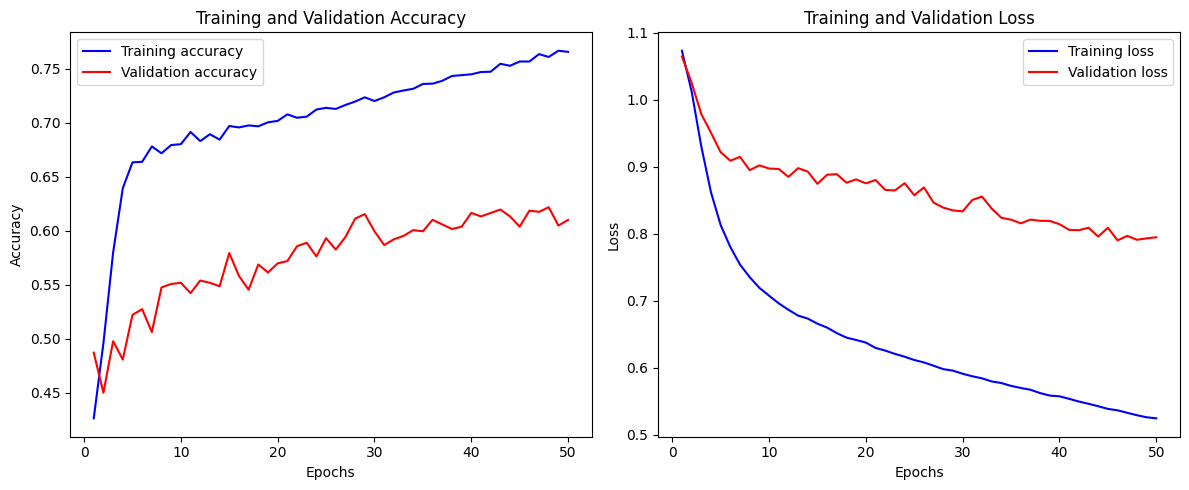

In [166]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [167]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_model3.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y3[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
整體驗證集準確度 (Overall Accuracy): 0.5612

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5625    0.8592    0.6799       419
     1分 (普通)     0.4223    0.3495    0.3825       412
      2分 (好)     0.8212    0.4468    0.5787       329

    accuracy                         0.5612      1160
   macro avg     0.6020    0.5518    0.5470      1160
weighted avg     0.5861    0.5612    0.5456      1160



In [188]:
cnn_model3.save("models/cnn_base_model3.keras")

In [174]:
cnn_model4  =  create_model_2(6)
cnn_epochs_metrics_4 = cnn_model4.fit(X[train_indices[3]], y4[train_indices[3]],  validation_data=(X[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 20)

Model: "sequential_79"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_34 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4449 - loss: 1.0661 - val_accuracy: 0.4741 - val_loss: 1.0496
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4795 - loss: 1.0225 - val_accuracy: 0.5237 - val_loss: 1.0010
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5470 - loss: 0.9770 - val_accuracy: 0.5711 - val_loss: 0.9619
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5820 - loss: 0.9364 - val_accuracy: 0.5700 - val_loss: 0.9318
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5928 - loss: 0.9016 - val_accuracy: 0.5776 - val_loss: 0.8965
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5959 - loss: 0.8735 - val_accuracy: 0.5808 - val_loss: 0.8778
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6027 - loss: 0.8505 - val_accuracy: 0.5873 - val_loss: 0.8546
Epoch 8/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6046 - loss: 0.8311 - val_accuracy: 0.

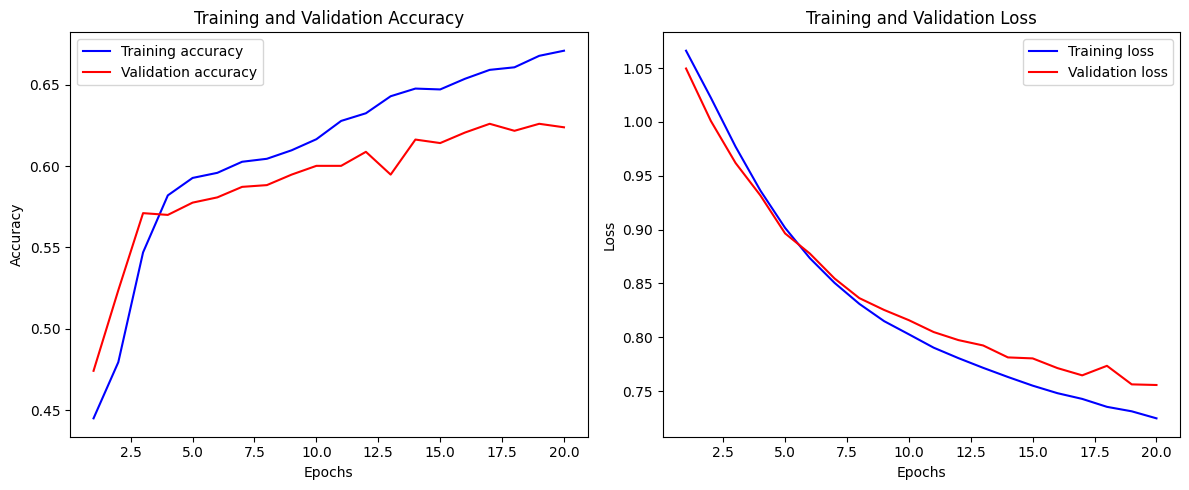

In [175]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [180]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_model4.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y4[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
整體驗證集準確度 (Overall Accuracy): 0.6716

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.7438    0.5593    0.6385       270
     1分 (普通)     0.5853    0.8423    0.6907       501
      2分 (好)     0.8729    0.5296    0.6592       389

    accuracy                         0.6716      1160
   macro avg     0.7340    0.6437    0.6628      1160
weighted avg     0.7186    0.6716    0.6680      1160



In [189]:
cnn_model4.save("models/cnn_base_model4.keras")

In [177]:
cnn_model5  =  create_model_2(6)
cnn_epochs_metrics_5 = cnn_model5.fit(X[train_indices[4]], y5[train_indices[4]],  validation_data=(X[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 20)

Model: "sequential_80"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3896 - loss: 1.0738 - val_accuracy: 0.4076 - val_loss: 1.0574
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4662 - loss: 1.0385 - val_accuracy: 0.4397 - val_loss: 1.0431
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5248 - loss: 1.0011 - val_accuracy: 0.4914 - val_loss: 1.0154
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5673 - loss: 0.9622 - val_accuracy: 0.5086 - val_loss: 0.9938
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5861 - loss: 0.9272 - val_accuracy: 0.5212 - val_loss: 0.9762
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5908 - loss: 0.8986 - val_accuracy: 0.5454 - val_loss: 0.9507
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6001 - loss: 0.8730 - val_accuracy: 0.5557 - val_loss: 0.9354
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6021 - loss: 0.8515 - val_accuracy: 0.

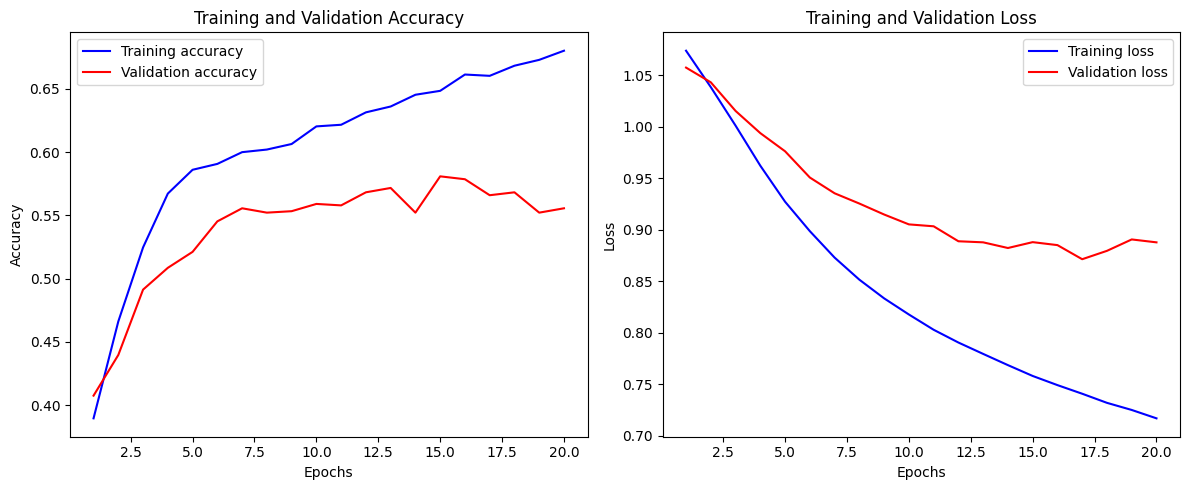

In [181]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [179]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_model5.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y5[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
整體驗證集準確度 (Overall Accuracy): 0.5879

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5281    0.7399    0.6163       419
     1分 (普通)     0.5086    0.4027    0.4495       442
      2分 (好)     0.8700    0.6488    0.7433       299

    accuracy                         0.5879      1160
   macro avg     0.6355    0.5971    0.6030      1160
weighted avg     0.6088    0.5879    0.5855      1160



In [190]:
cnn_model5.save("models/cnn_base_model5.keras")

In [196]:
cnn_lstm_model1  =  create_model_3(6)
cnn_lstm_epochs_metrics_1 = cnn_lstm_model1.fit(X[train_indices[0]], y1[train_indices[0]],  validation_data=(X[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 20)

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_39 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_39 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4848 - loss: 1.2524 - val_accuracy: 0.4856 - val_loss: 1.1869
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4754 - loss: 1.1787 - val_accuracy: 0.4856 - val_loss: 1.1353
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4793 - loss: 1.1310 - val_accuracy: 0.4856 - val_loss: 1.1006
Epoch 4/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4822 - loss: 1.1031 - val_accuracy: 0.4856 - val_loss: 1.0739
Epoch 5/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4960 - loss: 1.0712 - val_accuracy: 0.4856 - val_loss: 1.0452
Epoch 6/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5326 - loss: 1.0114 - val_accuracy: 0.5642 - val_loss: 0.9787
Epoch 7/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5701 - loss: 0.9590 - val_accuracy: 0.5730 - val_loss: 0.9411
Epoch 8/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5724 - loss: 0.9370 - val_acc

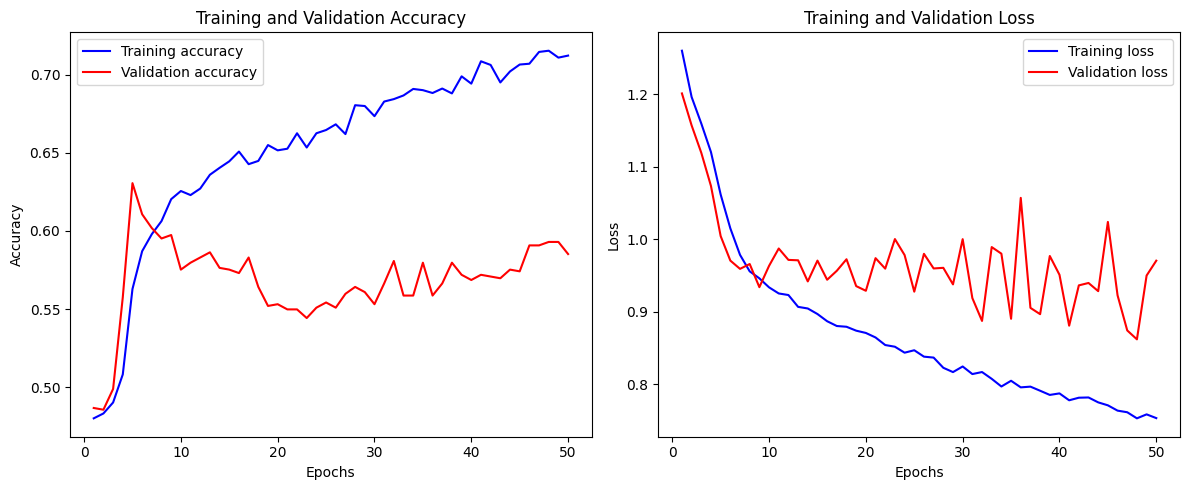

In [195]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [198]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_lstm_model1.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y1[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
整體驗證集準確度 (Overall Accuracy): 0.7164

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.2500    0.0084    0.0163       119
     1分 (普通)     0.6697    0.8767    0.7593       592
      2分 (好)     0.8163    0.6927    0.7494       449

    accuracy                         0.7164      1160
   macro avg     0.5787    0.5259    0.5083      1160
weighted avg     0.6834    0.7164    0.6793      1160



In [202]:
cnn_lstm_model1.save("models/cnn_lstm_base_model1.keras")

In [203]:
cnn_lstm_model2  =  create_model_3(6)
cnn_lstm_epochs_metrics_2 = cnn_lstm_model2.fit(X[train_indices[1]], y2[train_indices[1]],  validation_data=(X[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 13)

Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_41 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_41 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_60 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4853 - loss: 1.2555 - val_accuracy: 0.5176 - val_loss: 1.1980
Epoch 2/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4926 - loss: 1.1920 - val_accuracy: 0.5176 - val_loss: 1.1504
Epoch 3/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4921 - loss: 1.1479 - val_accuracy: 0.5176 - val_loss: 1.1123
Epoch 4/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4957 - loss: 1.1162 - val_accuracy: 0.5176 - val_loss: 1.0755
Epoch 5/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5613 - loss: 1.0425 - val_accuracy: 0.6791 - val_loss: 0.9716
Epoch 6/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6366 - loss: 0.9414 - val_accuracy: 0.6692 - val_loss: 0.9293
Epoch 7/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6457 - loss: 0.8973 - val_accuracy: 0.5681 - val_loss: 1.0256
Epoch 8/13
240/240 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6468 - loss: 0.8856 - val_accu

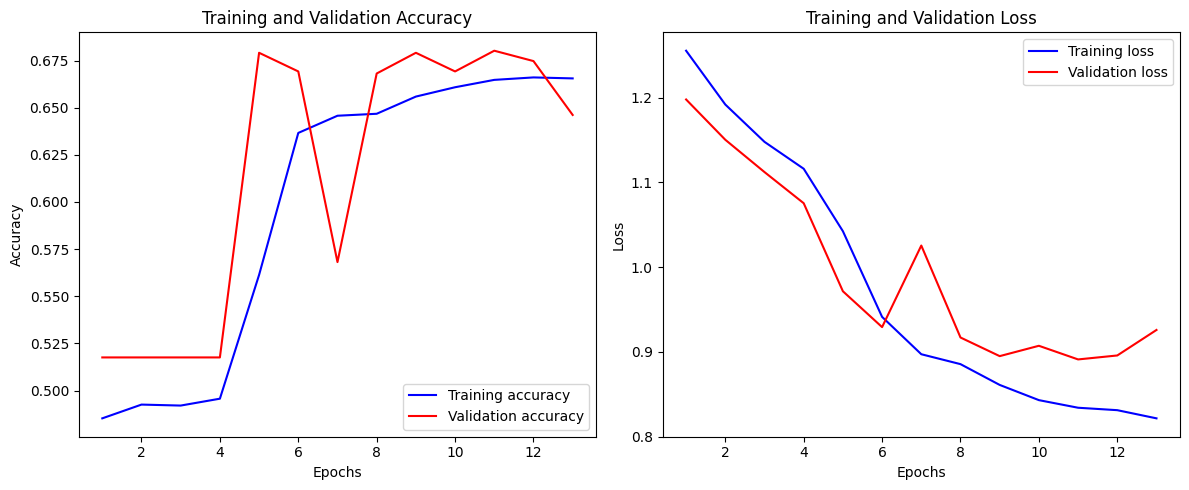

In [204]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [205]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_lstm_model2.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y2[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
整體驗證集準確度 (Overall Accuracy): 0.6138

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       240
     1分 (普通)     0.5589    0.7420    0.6375       531
      2分 (好)     0.6989    0.8175    0.7536       389

    accuracy                         0.6138      1160
   macro avg     0.4193    0.5198    0.4637      1160
weighted avg     0.4902    0.6138    0.5445      1160



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [ ]:
cnn_lstm_model2.save("models/cnn_lstm_base_model2.keras")

In [209]:
cnn_lstm_model3  =  create_model_3(6)
cnn_lstm_epochs_metrics_3 = cnn_lstm_model3.fit(X[train_indices[2]], y3[train_indices[2]],  validation_data=(X[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 25)

Model: "sequential_88"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_43 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_43 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_62 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3898 - loss: 1.3281 - val_accuracy: 0.3686 - val_loss: 1.2934
Epoch 2/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4013 - loss: 1.2622 - val_accuracy: 0.3252 - val_loss: 1.2472
Epoch 3/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4568 - loss: 1.1832 - val_accuracy: 0.4110 - val_loss: 1.1677
Epoch 4/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5117 - loss: 1.1036 - val_accuracy: 0.5169 - val_loss: 1.1114
Epoch 5/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5459 - loss: 1.0458 - val_accuracy: 0.5445 - val_loss: 1.0443
Epoch 6/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5742 - loss: 1.0044 - val_accuracy: 0.5392 - val_loss: 1.0126
Epoch 7/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5714 - loss: 0.9845 - val_accuracy: 0.5922 - val_loss: 1.0016
Epoch 8/25
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5695 - loss: 0.9804 - val_accu

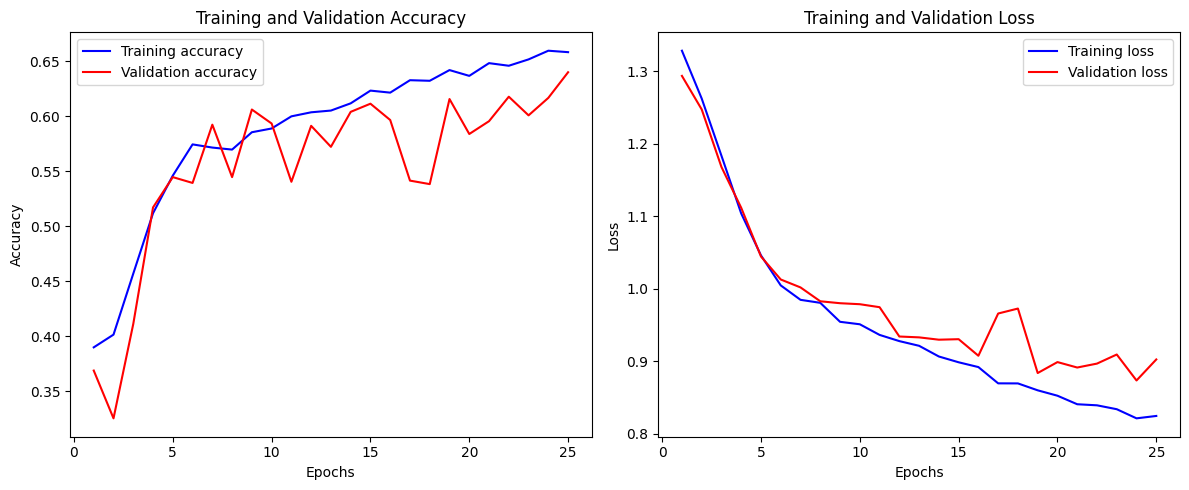

In [210]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [211]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_lstm_model3.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y3[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
整體驗證集準確度 (Overall Accuracy): 0.5853

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.6255    0.7136    0.6667       419
     1分 (普通)     0.4186    0.3932    0.4055       412
      2分 (好)     0.7390    0.6626    0.6987       329

    accuracy                         0.5853      1160
   macro avg     0.5944    0.5898    0.5903      1160
weighted avg     0.5842    0.5853    0.5830      1160



In [213]:
cnn_lstm_model3.save("models/cnn_lstm_base_model3.keras")

In [223]:
cnn_lstm_model4  =  create_model_3(6)
cnn_lstm_epochs_metrics_4 = cnn_lstm_model4.fit(X[train_indices[3]], y4[train_indices[3]],  validation_data=(X[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 20)

Model: "sequential_93"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_48 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_48 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_67 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4146 - loss: 1.3057 - val_accuracy: 0.4494 - val_loss: 1.2615
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4402 - loss: 1.2437 - val_accuracy: 0.4494 - val_loss: 1.2098
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4543 - loss: 1.1919 - val_accuracy: 0.4494 - val_loss: 1.1484
Epoch 4/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4808 - loss: 1.1285 - val_accuracy: 0.5259 - val_loss: 1.0675
Epoch 5/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5216 - loss: 1.0738 - val_accuracy: 0.5582 - val_loss: 1.0057
Epoch 6/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5263 - loss: 1.0514 - val_accuracy: 0.5582 - val_loss: 0.9837
Epoch 7/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5321 - loss: 1.0306 - val_accuracy: 0.5668 - val_loss: 0.9621
Epoch 8/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5428 - loss: 1.0108 - val_accu

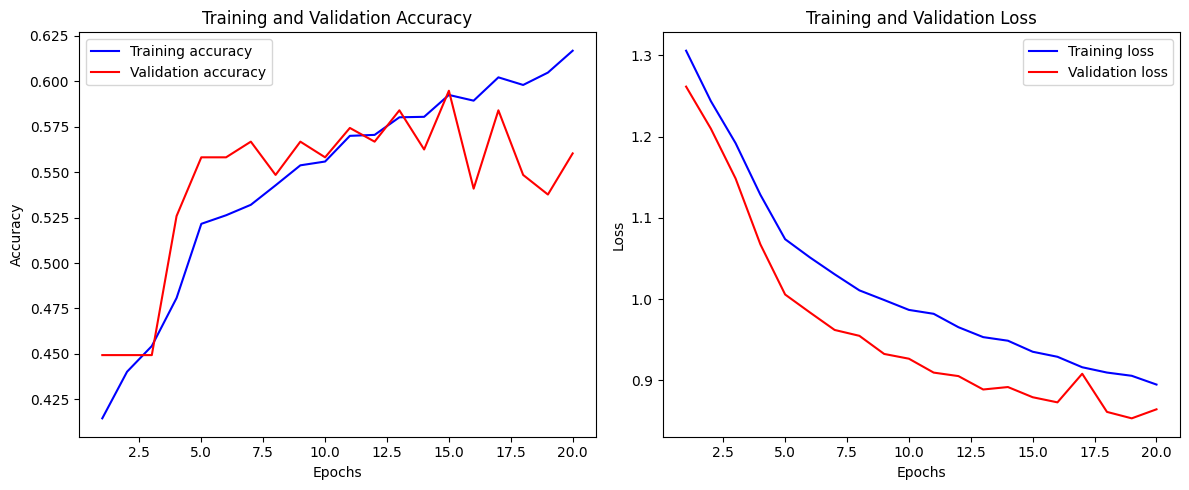

In [226]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [227]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_lstm_model4.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y4[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
整體驗證集準確度 (Overall Accuracy): 0.6172

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5074    0.5111    0.5092       270
     1分 (普通)     0.5470    0.6627    0.5993       501
      2分 (好)     0.8754    0.6324    0.7343       389

    accuracy                         0.6172      1160
   macro avg     0.6433    0.6021    0.6143      1160
weighted avg     0.6479    0.6172    0.6236      1160



In [229]:
cnn_lstm_model4.save("models/cnn_lstm_base_model4.keras")

In [230]:
cnn_lstm_model5  =  create_model_3(6)
cnn_lstm_epochs_metrics5 = cnn_lstm_model5.fit(X[train_indices[4]], y5[train_indices[4]],  validation_data=(X[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 20)

Model: "sequential_94"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_49 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_49 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_68 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.3540 - loss: 1.3197 - val_accuracy: 0.3674 - val_loss: 1.2638
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3804 - loss: 1.2470 - val_accuracy: 0.4673 - val_loss: 1.2024
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4278 - loss: 1.1976 - val_accuracy: 0.5373 - val_loss: 1.1367
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.4593 - loss: 1.1262 - val_accuracy: 0.4753 - val_loss: 1.0584
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5113 - loss: 1.0577 - val_accuracy: 0.5649 - val_loss: 1.0015
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5513 - loss: 1.0097 - val_accuracy: 0.5568 - val_loss: 0.9690
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5536 - loss: 0.9877 - val_accuracy: 0.6131 - val_loss: 0.9290
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5557 - loss: 0.9694 - val_accu

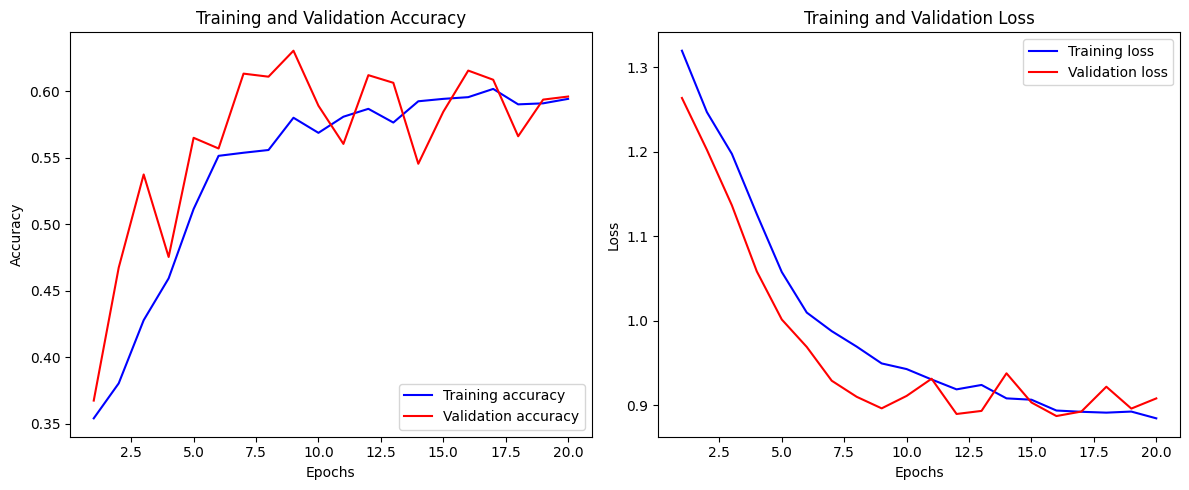

In [233]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_epochs_metrics5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [235]:
cnn_lstm_model4.save("models/cnn_lstm_base_model5.keras")

In [234]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = cnn_lstm_model5.predict(X[test_indices]) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y5[test_indices].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
整體驗證集準確度 (Overall Accuracy): 0.6276

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5799    0.8138    0.6773       419
     1分 (普通)     0.5621    0.4299    0.4872       442
      2分 (好)     0.8419    0.6589    0.7392       299

    accuracy                         0.6276      1160
   macro avg     0.6613    0.6342    0.6346      1160
weighted avg     0.6407    0.6276    0.6208      1160



In [28]:
import matplotlib.pyplot as plt

In [29]:
#plot(to check whether overfit or not)
def draw_val_loss(metrics):
    plt.plot(metrics.history['loss'], label='loss')
    plt.plot(metrics.history['val_loss'], label='val_loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [ ]:
draw_val_loss(epochs_metrics_1)
draw_val_loss(epochs_metrics_2)
draw_val_loss(epochs_metrics_3)
draw_val_loss(epochs_metrics_4)
draw_val_loss(epochs_metrics_5)

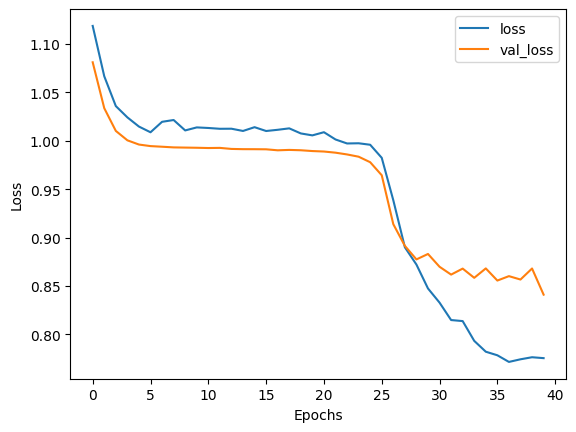

In [407]:
draw_val_loss(epochs_metrics_1)

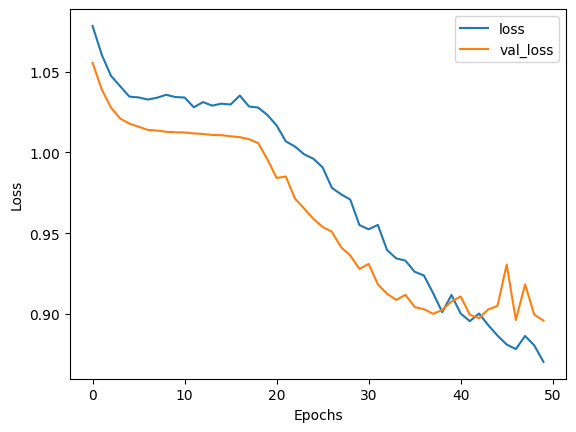

In [387]:
draw_val_loss(epochs_metrics_2)

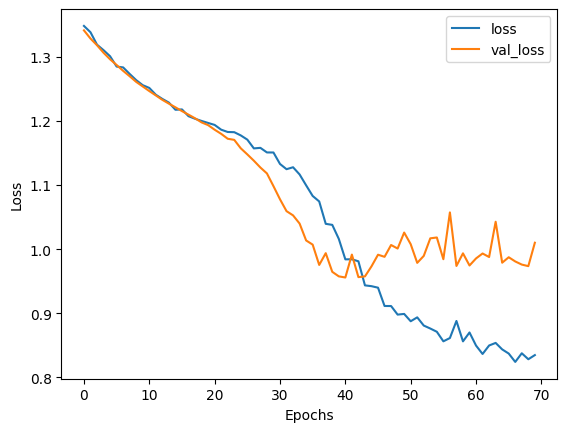

In [355]:
draw_val_loss(epochs_metrics_3)

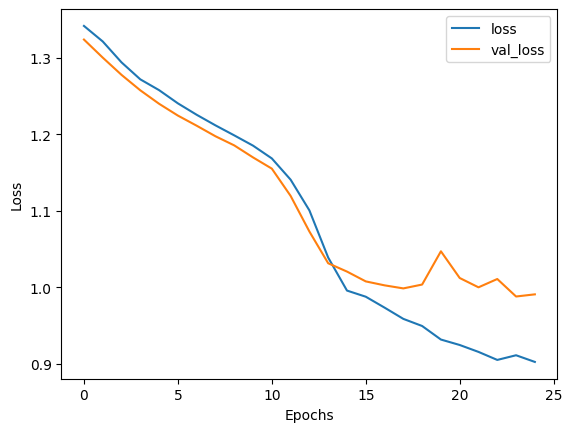

In [361]:
draw_val_loss(epochs_metrics_4)

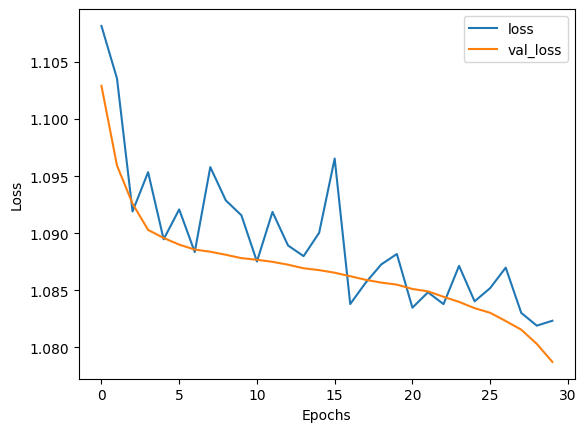

In [412]:
draw_val_loss(epochs_metrics_5) 

In [4]:
def show_predict_result(model, x_test, y_test):
    ans = model.predict(x_test)
    predicted_values = np.argmax(ans, axis=1)
    true_values = y_test
    #print('Predicted values:\n',predicted_values)
    #print('True values:\n', true_values)
    count = 0
    for i in range(len(true_values)):
        if predicted_values[i] == true_values[i]:
            count += 1
    accuracy = count/len(true_values)
    print('accuracy=', accuracy)
    return (accuracy, predicted_values)

In [ ]:
acc1, predicted_value1 = show_predict_result(model1, X[test_indices], y1[test_indices])
acc2, predicted_value2 = show_predict_result(model2, X[test_indices], y2[test_indices])
acc3, predicted_value3 = show_predict_result(model3, X[test_indices], y3[test_indices]) 
acc4, predicted_value4 = show_predict_result(model4, X[test_indices], y4[test_indices]) 
acc5, predicted_value5 = show_predict_result(model5, X[test_indices], y5[test_indices])

In [95]:
from joblib import dump, load

In [ ]:
dump(model1, 'models/model1_cnn.joblib')
dump(model2, 'models/model2_cnn.joblib')
dump(model3, 'models/model3_cnn.joblib')
dump(model4, 'models/model4_cnn.joblib')
dump(model5, 'models/model5_cnn.joblib')

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,571 (17.86 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,048 (11.91 KB)

以lstm的模型來預測分數及生成評語

In [47]:
#事先保存
test_indices=[145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433, 1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443, 1444, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 1543, 1544, 1545, 1546, 1547, 1548, 1549, 1550, 1551, 1552, 1553, 1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102, 2313, 2314, 2315, 2316, 2317, 2318, 2319, 2320, 2321, 2322, 2323, 2324, 2325, 2326, 2327, 2328, 2329, 2330, 2331, 2332, 2333, 2334, 2335, 2336, 2337, 2338, 2339, 2340, 2341, 2342, 2433, 2434, 2435, 2436, 2437, 2438, 2439, 2440, 2441, 2442, 2443, 2444, 2445, 2446, 2447, 2448, 2449, 2450, 2451, 2452, 2453, 2454, 2455, 2456, 2457, 2458, 2459, 2460, 2461, 2462, 2869, 2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 2889, 2890, 2891, 2892, 2893, 2894, 2895, 2896, 2897, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2912, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 2928, 2959, 2960, 2961, 2962, 2963, 2964, 2965, 2966, 2967, 2968, 2969, 2970, 2971, 2972, 2973, 2974, 2975, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2988, 3168, 3169, 3170, 3171, 3172, 3173, 3174, 3175, 3176, 3177, 3178, 3179, 3180, 3181, 3182, 3183, 3184, 3185, 3186, 3187, 3188, 3189, 3190, 3191, 3192, 3193, 3194, 3195, 3196, 3197, 3198, 3199, 3200, 3201, 3202, 3203, 3204, 3205, 3206, 3207, 3208, 3209, 3210, 3211, 3212, 3213, 3214, 3215, 3216, 3217, 3218, 3219, 3220, 3221, 3222, 3223, 3224, 3225, 3226, 3227, 3228, 3229, 3230, 3231, 3232, 3233, 3234, 3235, 3236, 3237, 3238, 3239, 3240, 3241, 3242, 3243, 3244, 3245, 3246, 3247, 3248, 3249, 3250, 3251, 3252, 3253, 3254, 3255, 3256, 3257, 3348, 3349, 3350, 3351, 3352, 3353, 3354, 3355, 3356, 3357, 3358, 3359, 3360, 3361, 3362, 3363, 3364, 3365, 3366, 3367, 3368, 3369, 3370, 3371, 3372, 3373, 3374, 3375, 3376, 3377, 3378, 3379, 3380, 3381, 3382, 3383, 3384, 3385, 3386, 3387, 3388, 3389, 3390, 3391, 3392, 3393, 3394, 3395, 3396, 3397, 3398, 3399, 3400, 3401, 3402, 3403, 3404, 3405, 3406, 3407, 3438, 3439, 3440, 3441, 3442, 3443, 3444, 3445, 3446, 3447, 3448, 3449, 3450, 3451, 3452, 3453, 3454, 3455, 3456, 3457, 3458, 3459, 3460, 3461, 3462, 3463, 3464, 3465, 3466, 3467, 3468, 3469, 3470, 3471, 3472, 3473, 3474, 3475, 3476, 3477, 3478, 3479, 3480, 3481, 3482, 3483, 3484, 3485, 3486, 3487, 3488, 3489, 3490, 3491, 3492, 3493, 3494, 3495, 3496, 3497, 3827, 3828, 3829, 3830, 3831, 3832, 3833, 3834, 3835, 3836, 3837, 3838, 3839, 3840, 3841, 3842, 3843, 3844, 3845, 3846, 3847, 3848, 3849, 3850, 3851, 3852, 3853, 3854, 3855, 3856, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4109, 4110, 4111, 4112, 4113, 4114, 4115, 4116, 4117, 4118, 4119, 4120, 4121, 4122, 4123, 4124, 4125, 4126, 4127, 4128, 4129, 4130, 4131, 4132, 4133, 4134, 4135, 4136, 4137, 4138, 4139, 4140, 4141, 4142, 4143, 4144, 4145, 4146, 4147, 4148, 4149, 4150, 4151, 4152, 4153, 4154, 4155, 4156, 4309, 4310, 4311, 4312, 4313, 4314, 4315, 4316, 4317, 4318, 4319, 4320, 4321, 4322, 4323, 4324, 4325, 4326, 4327, 4328, 4329, 4330, 4331, 4332, 4333, 4334, 4335, 4336, 4337, 4455, 4456, 4457, 4458, 4459, 4460, 4461, 4462, 4463, 4464, 4465, 4466, 4467, 4468, 4469, 4470, 4471, 4472, 4473, 4474, 4475, 4476, 4477, 4478, 4479, 4480, 4481, 4482, 4483, 4484, 5056, 5057, 5058, 5059, 5060, 5061, 5062, 5063, 5064, 5065, 5066, 5067, 5068, 5069, 5070, 5071, 5072, 5073, 5074, 5075, 5076, 5077, 5078, 5079, 5080, 5081, 5082, 5083, 5084, 5085, 5236, 5237, 5238, 5239, 5240, 5241, 5242, 5243, 5244, 5245, 5246, 5247, 5248, 5249, 5250, 5251, 5252, 5253, 5254, 5255, 5256, 5257, 5258, 5259, 5260, 5261, 5262, 5263, 5322, 5323, 5324, 5325, 5326, 5327, 5328, 5329, 5330, 5331, 5332, 5333, 5334, 5335, 5336, 5337, 5338, 5339, 5340, 5341, 5342, 5343, 5344, 5345, 5346, 5347, 5348, 5349, 5350, 5351, 5559, 5560, 5561, 5562, 5563, 5564, 5565, 5566, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5578, 5579, 5580, 5701, 5702, 5703, 5704, 5705, 5706, 5707, 5708, 5709, 5710, 5711, 5712, 5713, 5714, 5715, 5716, 5717, 5718, 5719, 5720, 5721, 5722, 5723, 5724, 5725, 5726, 5727, 5728, 5729, 5730, 5879, 5880, 5881, 5882, 5883, 5884, 5885, 5886, 5887, 5888, 5889, 5890, 5891, 5892, 5893, 5894, 5895, 5896, 5897, 5898, 5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908]

In [48]:
random.shuffle(test_indices)

In [49]:
train_and_val_indices = list(set(range(sample_count))-set(test_indices))
print(len(train_and_val_indices))

4757


In [96]:
model1_cnn = load('models/model_cnn16_batch16/model1_epoch25.joblib')
model2_cnn= load('models/model_cnn16_batch16/model2_epoch30.joblib')
model3_cnn = load('models/model_cnn16_batch16/model3_epoch40.joblib')
model4_cnn = load('models/model_cnn16_batch16/model4_epoch25.joblib')
model5_cnn = load('models/model_cnn16_batch16/model5_epoch25.joblib')

model1_lstm = load('models/model_lstm16_batch16/model1_epoch40.joblib')
model2_lstm = load('models/model_lstm16_batch16/model2_epoch35.joblib')
model3_lstm = load('models/model_lstm16_batch16/model3_epoch150.joblib')
model4_lstm = load('models/model_lstm16_batch16/model4_epoch50.joblib')
model5_lstm = load('models/model_lstm16_batch16/model5_epoch30.joblib')

model1_lstm_cnn = load('models/model_cnn16_lstm16_batch16/model1_epoch25.joblib')
model2_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model2_epoch25.joblib')
model3_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model3_epoch40.joblib')
model4_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model4_epoch25.joblib')
model5_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model5_epoch20.joblib')
model5_lstm_cnn.summary()

FileNotFoundError: [Errno 2] No such file or directory: 'models/model_cnn16_batch16/model1_epoch25.joblib'

In [50]:
print('cnn')
cnn_acc1, cnn_predicted_value1 = show_predict_result(model1_cnn, X[test_indices], y1[test_indices])
cnn_acc2, cnn_predicted_value2 = show_predict_result(model2_cnn, X[test_indices], y2[test_indices])
cnn_acc3, cnn_predicted_value3 = show_predict_result(model3_cnn, X[test_indices], y3[test_indices])
cnn_acc4, cnn_predicted_value4 = show_predict_result(model4_cnn, X[test_indices], y4[test_indices])
cnn_acc5, cnn_predicted_value5 = show_predict_result(model5_cnn, X[test_indices], y5[test_indices])

cnn
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
accuracy= 0.6467013888888888
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
accuracy= 0.6267361111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
accuracy= 0.6345486111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
accuracy= 0.6215277777777778
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
accuracy= 0.5590277777777778


In [27]:
print('lstm')
lstm_acc1, lstm_predicted_value1 = show_predict_result(model1_lstm, X[test_indices], y1[test_indices])
lstm_acc2, lstm_predicted_value2 = show_predict_result(model2_lstm, X[test_indices], y2[test_indices])
lstm_acc3, lstm_predicted_value3 = show_predict_result(model3_lstm, X[test_indices], y3[test_indices])
lstm_acc4, lstm_predicted_value4 = show_predict_result(model4_lstm, X[test_indices], y4[test_indices])
lstm_acc5, lstm_predicted_value5 = show_predict_result(model5_lstm, X[test_indices], y5[test_indices])

lstm
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.6302083333333334
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
accuracy= 0.5416666666666666
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.5876736111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
accuracy= 0.4835069444444444
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.3298611111111111


In [28]:
print('lstm+cnn')
lstm_cnn_acc1, lstm_cnn_predicted_value1 = show_predict_result(model1_lstm_cnn, X[test_indices], y1[test_indices])
lstm_cnn_acc2, lstm_cnn_predicted_value2 = show_predict_result(model2_lstm_cnn, X[test_indices], y2[test_indices])
lstm_cnn_acc3, lstm_cnn_predicted_value3 = show_predict_result(model3_lstm_cnn, X[test_indices], y3[test_indices])
lstm_cnn_acc4, lstm_cnn_predicted_value4 = show_predict_result(model4_lstm_cnn, X[test_indices], y4[test_indices])
lstm_cnn_acc5, lstm_cnn_predicted_value5 = show_predict_result(model5_lstm_cnn, X[test_indices], y5[test_indices])

lstm+cnn
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
accuracy= 0.6154513888888888
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.5789930555555556
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
accuracy= 0.6111111111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
accuracy= 0.6449652777777778
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
accuracy= 0.3368055555555556


In [51]:
final_predicted_values = {'揮拍軌跡正確度': cnn_predicted_value1, '揮拍速度流暢度': cnn_predicted_value2, '手腕轉動時機正確度': lstm_cnn_predicted_value3, '擊球時機正確度': cnn_predicted_value4, '擊球位置正確度': cnn_predicted_value5}
df_predicted_values = pd.DataFrame(final_predicted_values)
print('predicted_value\n', df_predicted_values)
#change
true_values = {'揮拍軌跡正確度': y1[test_indices], '揮拍速度流暢度':  y2[test_indices], '手腕轉動時機正確度':  y3[test_indices], '擊球時機正確度':  y4[test_indices], '擊球位置正確度':  y5[test_indices]}
df_true_values = pd.DataFrame(true_values)
print('true_value\n', df_true_values)

predicted_value
       揮拍軌跡正確度  揮拍速度流暢度  手腕轉動時機正確度  擊球時機正確度  擊球位置正確度
0           2        1          2        2        1
1           1        1          1        0        0
2           2        2          2        2        2
3           1        1          2        1        1
4           1        0          1        1        1
...       ...      ...        ...      ...      ...
1147        2        2          2        2        1
1148        1        1          2        0        0
1149        2        2          2        2        2
1150        1        1          2        0        0
1151        1        1          0        1        1

[1152 rows x 5 columns]
true_value
       揮拍軌跡正確度  揮拍速度流暢度  手腕轉動時機正確度  擊球時機正確度  擊球位置正確度
0           2        1          1        1        1
1           1        1          0        0        0
2           2        2          2        2        2
3           1        1          0        0        0
4           0        0          0        0        0
...       

In [30]:
#歐式距離(平方開根號)
from scipy.spatial import distance

In [52]:
similar_d_acc_x_indexes = []
similar_d_acc_y_indexes = []
similar_d_acc_z_indexes = []

similar_d_ang_x_indexes = []
similar_d_ang_y_indexes = []
similar_d_ang_z_indexes = []

similar_acc_x_d = []
similar_acc_y_d = []
similar_acc_z_d = []

similar_ang_x_d = []
similar_ang_y_d = []
similar_ang_z_d = []

acc_x_vectors = np.array(df['x軸加速度'][train_and_val_indices].tolist())
acc_y_vectors = np.array(df['y軸加速度'][train_and_val_indices].tolist())
acc_z_vectors = np.array(df['z軸加速度'][train_and_val_indices].tolist())

ang_x_vectors = np.array(df['x軸角加速度'][train_and_val_indices].tolist())
ang_y_vectors = np.array(df['y軸角加速度'][train_and_val_indices].tolist())
ang_z_vectors = np.array(df['z軸角加速度'][train_and_val_indices].tolist())

count = 0
for target_vector in np.array(df['x軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_x_vectors]
    similar_d_acc_x_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_x_d.append(similar_d_acc_x_indexes[count])
    count += 1
print('x軸加速度完成!')

count = 0
for target_vector in np.array(df['y軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_y_vectors]
    similar_d_acc_y_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_y_d.append(similar_d_acc_y_indexes[count])
    count += 1
print('y軸加速度完成!')

count = 0
for target_vector in np.array(df['z軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_z_vectors]
    similar_d_acc_z_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_z_d.append(similar_d_acc_z_indexes[count])
    count += 1
print('z軸加速度完成!')

count = 0
for target_vector in np.array(df['x軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_x_vectors]
    similar_d_ang_x_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_x_d.append(similar_d_ang_x_indexes[count])
    count += 1
print('x軸角加速度完成!')

count = 0
for target_vector in np.array(df['y軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_y_vectors]
    similar_d_ang_y_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_y_d.append(similar_d_ang_y_indexes[count])
    count += 1
print('y軸角加速度完成!')

count = 0
for target_vector in np.array(df['z軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_z_vectors]
    similar_d_ang_z_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_z_d.append(similar_d_ang_z_indexes[count])
    count += 1
print('z軸角加速度完成!')

x軸加速度完成!
y軸加速度完成!
z軸加速度完成!
x軸角加速度完成!
y軸角加速度完成!
z軸角加速度完成!


In [57]:
indexes = {'x軸加速度索引': similar_d_acc_x_indexes, 'y軸加速度索引': similar_d_acc_y_indexes, 'z軸加速度索引': similar_d_acc_z_indexes, 'x軸角加速度索引': similar_d_ang_x_indexes, 'y軸角加速度索引': similar_d_ang_y_indexes, 'z軸角加速度索引': similar_d_ang_z_indexes}
df_index = pd.DataFrame(indexes)
score_str = ('揮拍軌跡正確度', '揮拍速度流暢度', '手腕轉動時機正確度', '擊球時機正確度', '擊球位置正確度')

法一(找出x,y,z加速度與角加速度最接近的向量，總共6個)

In [191]:
comments = []
for i in range(len(df_index)):
    comment = ''
    for string in str(df['評語'][df_index['x軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    for string in str(df['評語'][df_index['y軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    for string in str(df['評語'][df_index['z軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    
    for string in str(df['評語'][df_index['x軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    for string in str(df['評語'][df_index['y軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    for string in str(df['評語'][df_index['z軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    
    for j in range(5):
        if df_predicted_values[score_str[j]][i] == 0:
            comment += score_str[j] + '不佳' + ','

    if len(comment) != 0:
        comment = comment[:-1]

    comments.append(comment)

法二(分別找出x,y,z三軸加速度與角加速度最接近的向量，總共2個(加速度與角加速度各一個))=>最後用這個

In [61]:
comments_2 = []
for i in range(len(df_index)):
    comment = ''
    min_index = np.argmin([df_index['x軸加速度索引'][i], df_index['y軸加速度索引'][i], df_index['z軸加速度索引'][i]])
    if min_index == 0:
        for string in str(df['評語'][df_index['x軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','
    elif min_index == 1:
        for string in str(df['評語'][df_index['y軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','
    else:
        for string in str(df['評語'][df_index['z軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','

    min_index = np.argmin([df_index['x軸角加速度索引'][i], df_index['y軸角加速度索引'][i], df_index['z軸角加速度索引'][i]])
    if min_index == 0:
        for string in str(df['評語'][df_index['x軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    elif min_index == 1:
        for string in str(df['評語'][df_index['y軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    else:
        for string in str(df['評語'][df_index['z軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    
    for j in range(5):
        if df_predicted_values[score_str[j]][i] == 0:
            comment += score_str[j] + '不佳' + ','
    
    if len(comment) != 0:
        comment = comment[:-1]

    comments_2.append(comment)

In [37]:
import google.generativeai as genai
import time
import os

c:\Users\User\Desktop\badminton_final\badminton-venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model = genai.GenerativeModel('gemini-pro')

In [59]:
grade=('C', 'B', 'A')
'''
count = 0
print('origin comments:')
for comment in comments:
    print(count,comment)
    count += 1
'''
count = 0
print('correct comment')
for comment in df['評語'][test_indices]:
    print(count, comment)
    count += 1

count = 0
print('correct grade')
for i in range(len(test_indices)):
    #print(count, grade[df['揮拍軌跡正確度'][final_test_indices][i]], grade[df['揮拍速度流暢度'][final_test_indices][i]], grade[df['手腕轉動時機正確度'][final_test_indices][i]], grade[df['擊球時機正確度'][final_test_indices][i]], grade[df['擊球位置正確度'][final_test_indices][i]])
    print(count, grade[y1[test_indices][i]], grade[y2[test_indices][i]], grade[y3[test_indices][i]], grade[y4[test_indices][i]], grade[y5[test_indices][i]])
    count += 1

correct comment
0 擊球時可加快手臂擺速，提升揮拍流暢度
1 握拍不正確，導致擊球未正確使用手腕，擊球位置也太低
2 標準
3 揮拍不流暢，擊球時間誤差大，擊球點誤差大導致揮拍軌跡不正確
4 動作不完整，擊球未使用手腕
5 標準
6 標準
7 標準
8 標準
9 標準
10 揮拍不流暢，擊球時間誤差大，擊球點誤差大導致揮拍軌跡不正確
11 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
12 擊球點太低導致揮拍動作不夠正確
13 擊球時可加快手臂擺速及增加手腕轉動
14 揮拍動作不夠完整
15 有幾拍手腕轉動不太足夠
16 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
17 擊球時手臂擺速可再加快
18 揮拍動作不夠完整
19 擊球時未使用手腕，擊球位置不正確
20 揮拍動作不完整，揮拍不流暢，擊球未使用手腕，擊球位置誤差大
21 標準
22 標準
23 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
24 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
25 標準
26 揮拍時引拍不夠完整，手腕使用較少，擊球點太低
27 揮拍動作不夠完整
28 標準
29 揮拍動作可再加強引拍動作，讓動作更完整，擊球時手腕可多轉動一些
30 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
31 揮拍不流暢，擊球時手腕轉動太少，擊球位置誤差大
32 擊球時手臂擺速可再加快
33 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
34 動作不完整，擊球未使用手腕
35 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
36 握拍不正確，揮拍動作不完整，擊球時未使用手腕，擊球時間及位置誤差大
37 手腕使用較少
38 揮拍動作可再完整些
39 有幾拍手腕轉動不太足夠
40 揮拍不流暢，擊球未使用手腕，擊球時間及位置誤差大
41 擊球時手臂擺速可再加快
42 擊球時手臂擺速可再加快
43 擊球時手腕可再轉動多一點，擊球點可再高一點，因擊球點太低導致揮拍軌跡不夠正確
44 標準
45 擊球時手腕轉動太少
46 揮拍動作不完整，擊球時未使用手腕，擊球位置不正確
47 揮拍不流暢，擊球時手腕轉動太少，擊球位置誤差大
48 擊球時可加快手臂擺速，提升揮拍流

In [62]:
count = 0
for comment in comments_2:
    if len(comment) == 0 or (df_predicted_values['揮拍軌跡正確度'][count] == 2 and df_predicted_values['揮拍速度流暢度'][count] == 2 and df_predicted_values['手腕轉動時機正確度'][count] == 2 and df_predicted_values['擊球時機正確度'][count] == 2 and df_predicted_values['擊球位置正確度'][count] == 2):
        res = model.generate_content(f'''現在你是一個羽球教練，要對學生的揮拍動作給出評語，如果這個學生高遠球的揮拍動作標準，那評語要給甚麼?
                                    給評語的注意事項:
                                    1.不要用條列式的方式 
                                    2.不要出現任何前情提要的字眼，直接講述評語就好 
                                    3.評語敘述不要太誇張，簡短且陳述事實就好''')
    else:
        res = model.generate_content(f'''現在你是一個羽球教練，要對學生的揮拍動作給出評語，雙引號內的文字內容是學生在高遠球揮拍時需改進的地方或做得很好的地方:"{comment}"。
                                    請根據雙引號內的內容，給出學生貼切的評語，讓他能知道高遠球揮拍動作能如何改進或是稱讚她哪裡做得很好。
                                    給評語的注意事項:
                                    1.不要用條列式的方式 
                                    2.要出現任何前情提要的字眼，直接講述評語就好 
                                    3.盡量精簡''')
    #print(f'''
    #5個面向的等第({count}):
    #揮拍軌跡正確度:{grade[df_predicted_values['揮拍軌跡正確度'][count]]}
    #揮拍速度流暢度:{grade[df_predicted_values['揮拍速度流暢度'][count]]}
    #手腕轉動時機正確度:{grade[df_predicted_values['手腕轉動時機正確度'][count]]}
    #擊球時機正確度:{grade[df_predicted_values['擊球時機正確度'][count]]}
    #擊球位置正確度:{grade[df_predicted_values['擊球位置正確度'][count]]}
    #評語:{res.text}''')
    print(count, grade[df_predicted_values['揮拍軌跡正確度'][count]], grade[df_predicted_values['揮拍速度流暢度'][count]], grade[df_predicted_values['手腕轉動時機正確度'][count]], grade[df_predicted_values['擊球時機正確度'][count]], grade[df_predicted_values['擊球位置正確度'][count]], res.text)
    
    count += 1
    time.sleep(5)

0 A B A A B 你的高遠球揮拍動作準確俐落，揮臂角度到位，擊球點抓得很好。
1 B B B C C 高遠球上拍時，你的擊球點需要調整，確保你擊中球的最高點，這樣才能讓球飛得更高遠。揮拍姿勢也要注意，保持流暢和規律，這將有助於你更準確地擊中球。
2 A A A A A 你的高遠球揮拍動作相當標準，上拍高聳、揮臂順暢，擊球時拍面平穩，飛行距離與高度都表現得很好。
3 B B A B B 手腕在擊球時應更靈活地轉動，讓揮拍動作更加完整，才能獲得更大的擊球力道。
4 B C B B B 你的揮拍動作還有進步的空間，擊球時要善用手腕的力量，才能讓球飛得更遠。
5 A A C A A 你的揮拍動作稍嫌卡頓，手臂擺速可以加快一些。這會讓球拍揮向球的時機更準確，進而擊出更穩定的高遠球。
6 A B C A B 你的揮拍動作堪稱教科書典範，時機拿捏精準，手臂伸展充分，拍面控制得宜，創造了完美的弧線和高度。
7 A B C A B 你揮拍時手臂擺速偏慢，流暢度不足。這會影響擊球點的精準度，建議加快手臂擺動，提升揮拍的整體流暢度。
8 A A C A A "正確" 高遠球揮拍時，你的手腕動作做得很好，後揮時有確實將球拍擺在頭頂後方，並且在擊球點時透過手腕的揮動將球送出，讓球有良好的飛行弧度和距離。
9 A A C A A 「擊球時手臂擺速可再加快」，這說明你的高遠球揮拍動作中，手臂擺動的幅度不夠大或速度不夠快。想要改善，可以在練習時多注意加速手臂的擺動，讓球拍加速擊球，提高擊球的力量和距離。
10 B B B B B 你的揮拍時機需要調整，更早或更晚一點才能擊到甜區。同時，手腕的使用能提升擊球的力量和準確度，可以多多練習手腕的靈活性。
11 B B A B C 揮拍動作的完整性和準確性是高遠球成功的關鍵所在。在擊球時，留意揮拍的後引並確保在最高點擊球，將有助於提升擊球力量和準度。
12 A A C B B 你的擊球位置需要調整，這樣才能打出更有深度的遠球。
13 B B C B C 身為你的教練，我觀察到你在高遠球揮拍時，擊球時間和位置的掌控有些許落差，導致揮拍不夠流暢。建議你可以多加練習，找到最適合自己的擊球點和時機，這樣才能揮出更穩定的高遠球。
14 B C A B B 你的高遠球揮拍動作很流暢，但請注意使用手腕的力量。
15 B B B B B 你的高遠球揮拍動作還需要加強

KeyboardInterrupt: 